## 1. Imports and Setup

In [3]:
import sys
sys.path.insert(0, "C:/Edu/VATSA")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from pathlib import Path
from PIL import Image
import librosa
import torchvision.transforms as transforms

# Module imports
from modules.visual.encoder import VATSA_VisualEncoder
from modules.audio.encoder  import VATSA_AudioEncoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

CIFAR10_CLASSES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Consistent colors for all plots
CLASS_COLORS = [
    '#FF4444', '#FF8C00', '#FFD700', '#7CFC00', '#00CED1',
    '#1E90FF', '#9400D3', '#FF69B4', '#00FF7F', '#FF6347'
]

COLOR_MAP = {cls: COLOR for cls, COLOR in zip(CIFAR10_CLASSES, CLASS_COLORS)}
print("Setup complete")

c:\Edu\VATSA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Setup complete


## 2. Load Visual Encoder

In [4]:
visual_encoder = VATSA_VisualEncoder(
    embedding_dim   = 512,
    freeze_backbone = True
).to(DEVICE)

checkpoint = torch.load(
    "C:/Edu/VATSA/modules/visual/vatsa_visual_encoder_cifar10_deeper_unfreeze.pth",
    map_location=DEVICE
)
state = {
    k: v for k, v in checkpoint["model_state"].items()
    if not k.startswith("classifier")
}
visual_encoder.load_state_dict(state, strict=False)
visual_encoder.eval()
print("Visual encoder loaded")

# Visual transform
visual_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

Visual encoder loaded


## 3. Load Audio Encoder

In [5]:
audio_encoder = VATSA_AudioEncoder(
    embedding_dim   = 512,
    freeze_backbone = True
).to(DEVICE)

checkpoint = torch.load(
    "C:/Edu/VATSA/modules/audio/vatsa_audio_encoder_transfer.pth",
    map_location=DEVICE
)
state = {
    k: v for k, v in checkpoint["model_state"].items()
    if not k.startswith("classifier")
}
audio_encoder.load_state_dict(state, strict=False)
audio_encoder.eval()
print("Audio encoder loaded")

SAMPLE_RATE = 16000
DURATION    = 5
N_SAMPLES   = SAMPLE_RATE * DURATION

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 23989.54it/s]
[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Audio encoder loaded


## 4. Extract Visual Embeddings from CIFAR-10

In [6]:
import torchvision

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_set = torchvision.datasets.CIFAR10(
    root='notebooks/data', train=False, download=True,
    transform=test_transform
)

# Sample 50 per class for t-SNE
SAMPLES_PER_CLASS = 50
visual_embeddings = []
visual_labels     = []

# Group indices by class
from collections import defaultdict
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(test_set):
    class_indices[label].append(idx)

print("Extracting visual embeddings...")
with torch.no_grad():
    for class_idx in range(10):
        indices = class_indices[class_idx][:SAMPLES_PER_CLASS]
        for idx in indices:
            img, label = test_set[idx]
            img_tensor = img.unsqueeze(0).to(DEVICE)
            embedding  = visual_encoder(img_tensor)["embedding"]
            visual_embeddings.append(embedding.cpu().numpy().squeeze())
            visual_labels.append(class_idx)

visual_embeddings = np.array(visual_embeddings)
visual_labels     = np.array(visual_labels)
print(f"Visual embeddings shape: {visual_embeddings.shape}")

100%|██████████| 170M/170M [00:56<00:00, 3.04MB/s] 
c:\Edu\VATSA\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Extracting visual embeddings...
Visual embeddings shape: (500, 512)


## 5. Extract Audio Embeddings from ESC-50

In [9]:
ESC50_META  = Path("data/audio/ESC-50/ESC-50-master/meta/esc50.csv")
ESC50_AUDIO = Path("data/audio/ESC-50/ESC-50-master/audio")

df = pd.read_csv(ESC50_META)

ESC50_TO_CIFAR10 = {
    'airplane'     : 0,
    'helicopter'   : 0,
    'car_horn'     : 1,
    'chirping_birds': 2,
    'cat'          : 3,
    'dog'          : 5,
    'frog'         : 6,
    'cow'          : 7,
    'pig'          : 7,
    'sheep'        : 7,
    'sea_waves'    : 8,
    'engine'       : 8,
    'train'        : 9,
}

audio_embeddings = []
audio_labels     = []

print("Extracting audio embeddings...")
with torch.no_grad():
    for esc_class, cifar_label in ESC50_TO_CIFAR10.items():
        subset = df[df['category'] == esc_class].head(5)
        for _, row in subset.iterrows():
            path = ESC50_AUDIO / row['filename']
            try:
                y, _ = librosa.load(str(path), sr=SAMPLE_RATE,
                                    duration=float(DURATION))
                if len(y) < N_SAMPLES:
                    y = np.pad(y, (0, N_SAMPLES - len(y)))
                else:
                    y = y[:N_SAMPLES]

                y = (y - y.mean()) / (y.std() + 1e-9)
                tensor = torch.tensor(
                    y, dtype=torch.float32
                ).unsqueeze(0).to(DEVICE)

                embedding = audio_encoder(tensor)["embedding"]
                audio_embeddings.append(
                    embedding.cpu().numpy().squeeze()
                )
                audio_labels.append(cifar_label)
            except Exception as e:
                print(f"  Skipping {path.name}: {e}")

# Add deer from synthesis
deer_dir = Path("data/audio/ESC-50/synthesised/deer")
for i, filepath in enumerate(list(deer_dir.glob("*.wav"))[:5]):
    try:
        y, _ = librosa.load(str(filepath), sr=SAMPLE_RATE,
                            duration=float(DURATION))
        if len(y) < N_SAMPLES:
            y = np.pad(y, (0, N_SAMPLES - len(y)))
        else:
            y = y[:N_SAMPLES]
        y = (y - y.mean()) / (y.std() + 1e-9)
        tensor = torch.tensor(
            y, dtype=torch.float32
        ).unsqueeze(0).to(DEVICE)
        embedding = audio_encoder(tensor)["embedding"]
        audio_embeddings.append(embedding.cpu().numpy().squeeze())
        audio_labels.append(4)  # deer
    except Exception as e:
        print(f"  Skipping {filepath.name}: {e}")

audio_embeddings = np.array(audio_embeddings)
audio_labels     = np.array(audio_labels)
print(f"Audio embeddings shape: {audio_embeddings.shape}")

Extracting audio embeddings...
  Skipping deer_synth_000.wav: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
  Skipping deer_synth_001.wav: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
  Skipping deer_synth_002.wav: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
  Skipping deer_synth_003.wav: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
  Skipping deer_synth_004.wav: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
Audio embeddings shape: (65, 512)


## 6. t-SNE — Visual Embeddings

Running t-SNE on visual embeddings...
Done


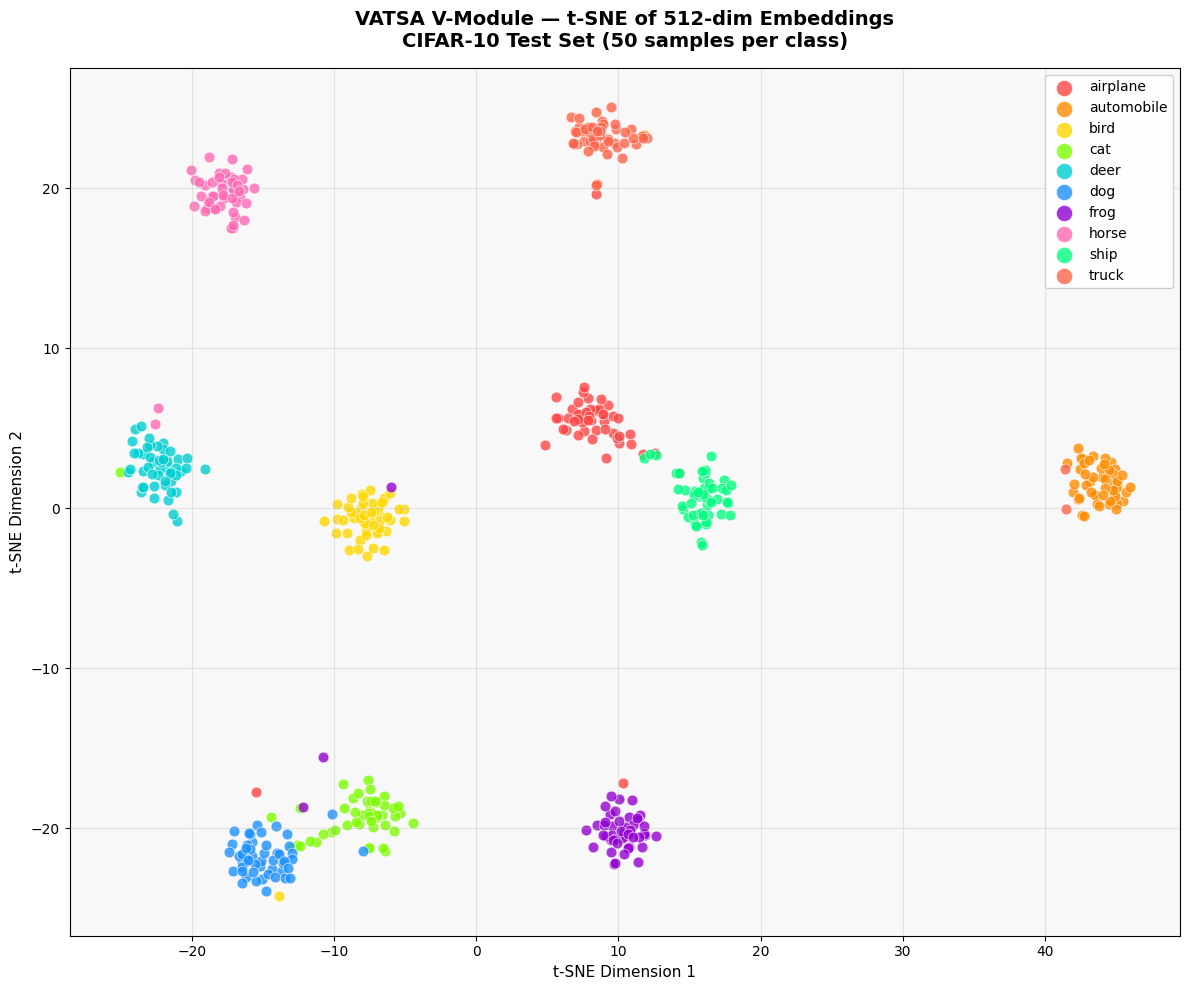

Saved vatsa_visual_tsne.png


In [15]:
print("Running t-SNE on visual embeddings...")
tsne_visual = TSNE(n_components=2, random_state=42,
                   perplexity=30, init='pca',learning_rate='auto', max_iter=1000)
visual_2d   = tsne_visual.fit_transform(visual_embeddings)
print("Done")

fig, ax = plt.subplots(figsize=(12, 10))

for class_idx, class_name in enumerate(CIFAR10_CLASSES):
    mask = visual_labels == class_idx
    ax.scatter(
        visual_2d[mask, 0], visual_2d[mask, 1],
        c     = COLOR_MAP[class_name],
        label = class_name,
        s     = 60,
        alpha = 0.8,
        edgecolors = 'white',
        linewidths = 0.5
    )

ax.set_title("VATSA V-Module — t-SNE of 512-dim Embeddings\n"
             "CIFAR-10 Test Set (50 samples per class)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.legend(loc='upper right', fontsize=10,
          framealpha=0.9, markerscale=1.5)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig("vatsa_visual_tsne.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved vatsa_visual_tsne.png")

## 7. t-SNE — Audio Embeddings

Running t-SNE on audio embeddings...
Done


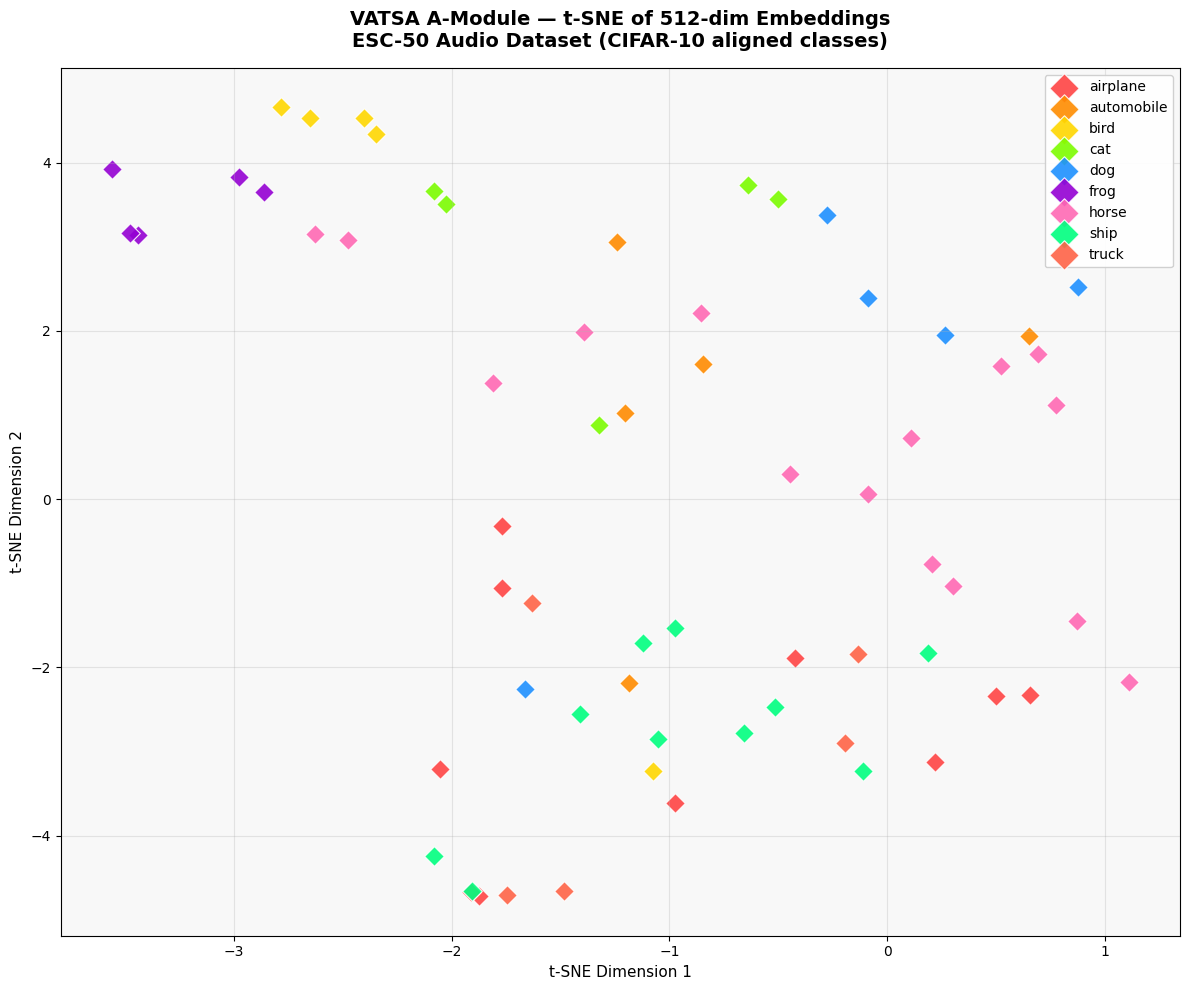

Saved vatsa_audio_tsne.png


In [18]:
print("Running t-SNE on audio embeddings...")
tsne_audio = TSNE(n_components=2, random_state=42,
                  perplexity=min(30, len(audio_embeddings)//2), init='pca',learning_rate='auto',
                  max_iter=1000)
audio_2d   = tsne_audio.fit_transform(audio_embeddings)
print("Done")

fig, ax = plt.subplots(figsize=(12, 10))

for class_idx, class_name in enumerate(CIFAR10_CLASSES):
    mask = audio_labels == class_idx
    if mask.sum() == 0:
        continue
    ax.scatter(
        audio_2d[mask, 0], audio_2d[mask, 1],
        c     = COLOR_MAP[class_name],
        label = class_name,
        s     = 100,
        alpha = 0.9,
        edgecolors = 'white',
        linewidths = 0.8,
        marker = 'D'   # diamond for audio to distinguish from visual
    )

ax.set_title("VATSA A-Module — t-SNE of 512-dim Embeddings\n"
             "ESC-50 Audio Dataset (CIFAR-10 aligned classes)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.legend(loc='upper right', fontsize=10,
          framealpha=0.9, markerscale=1.5)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig("vatsa_audio_tsne.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved vatsa_audio_tsne.png")

## 8. Side by Side Comparison

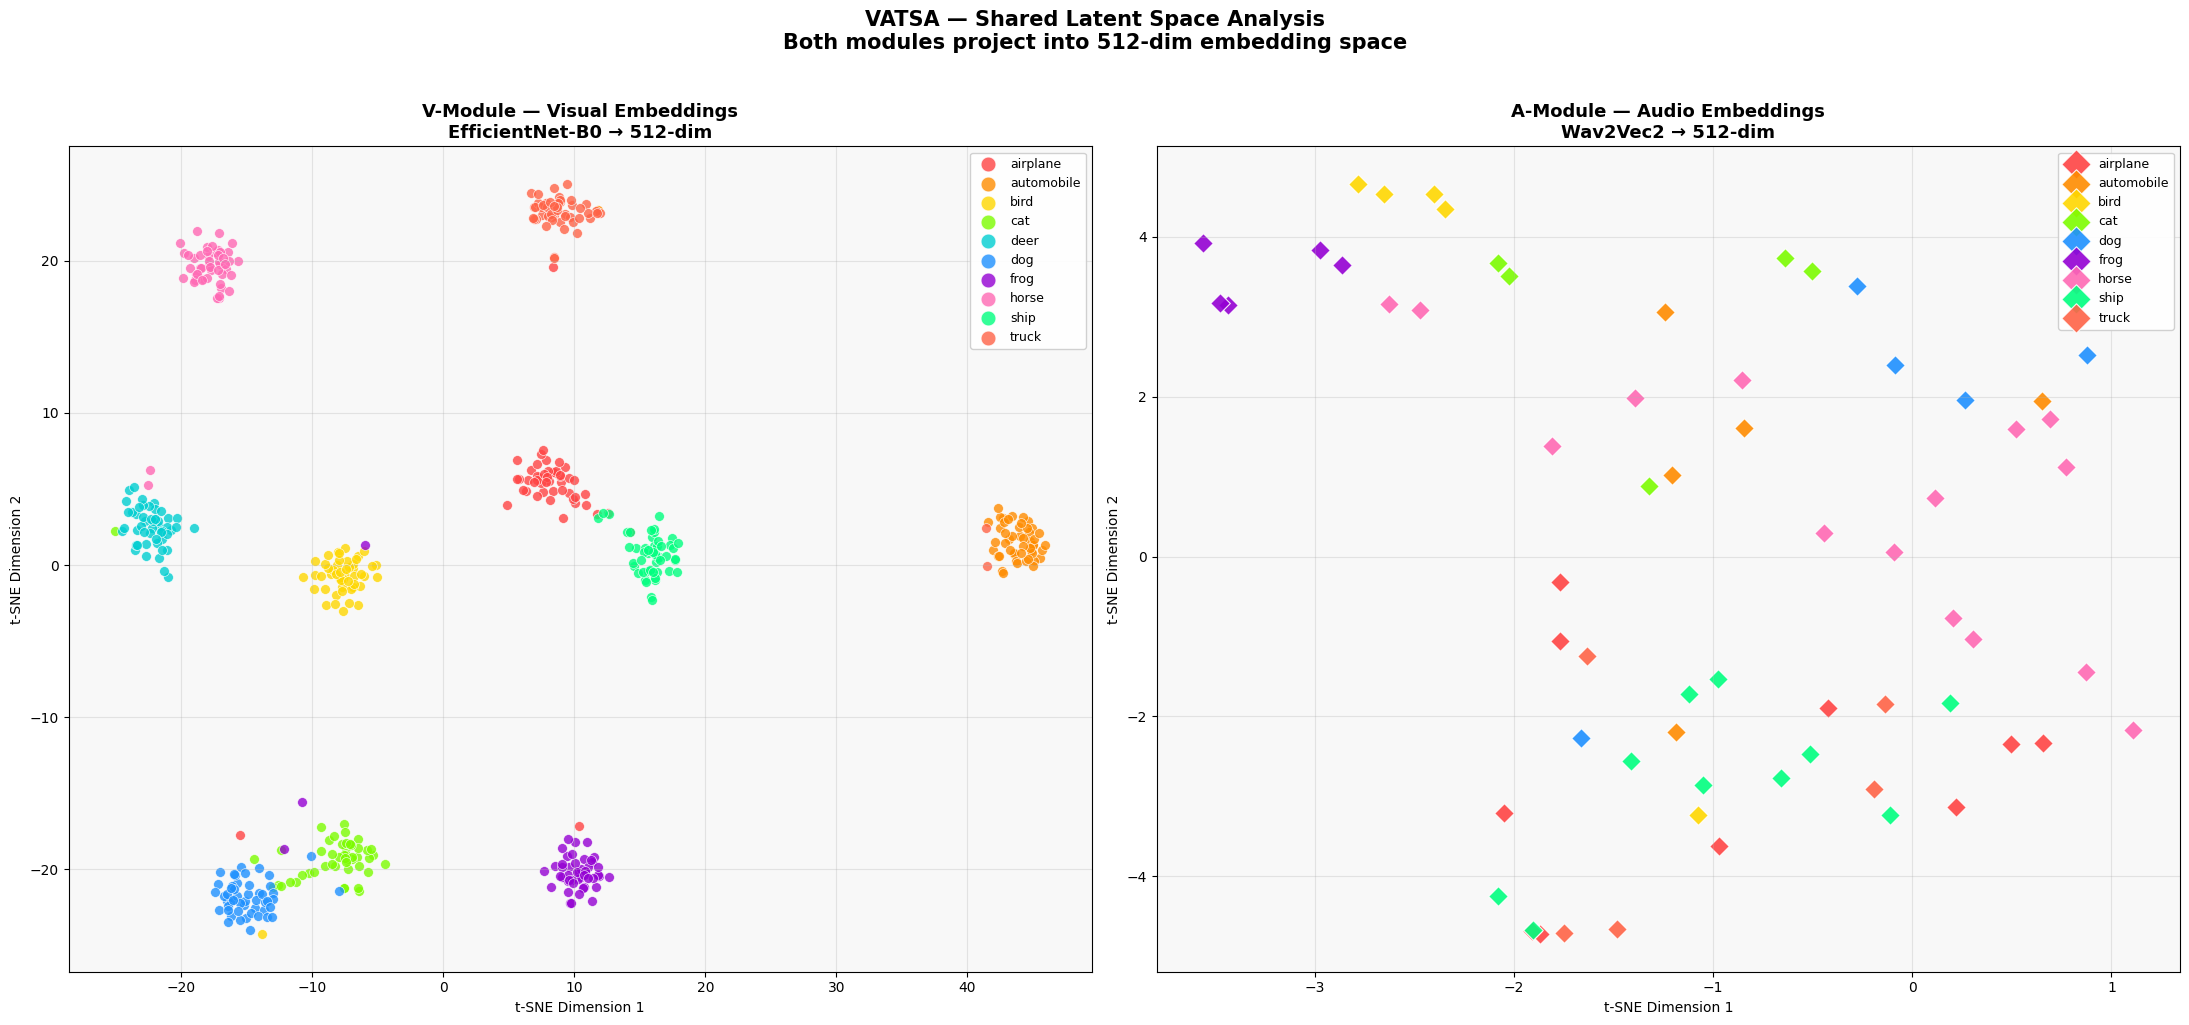

Saved vatsa_embedding_comparison.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))

# Visual
for class_idx, class_name in enumerate(CIFAR10_CLASSES):
    mask = visual_labels == class_idx
    axes[0].scatter(
        visual_2d[mask, 0], visual_2d[mask, 1],
        c          = COLOR_MAP[class_name],
        label      = class_name,
        s          = 50,
        alpha      = 0.8,
        edgecolors = 'white',
        linewidths = 0.5
    )

axes[0].set_title("V-Module — Visual Embeddings\n"
                  "EfficientNet-B0 → 512-dim",
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel("t-SNE Dimension 1")
axes[0].set_ylabel("t-SNE Dimension 2")
axes[0].legend(fontsize=9, framealpha=0.9, markerscale=1.5)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('#F8F8F8')

# Audio
for class_idx, class_name in enumerate(CIFAR10_CLASSES):
    mask = audio_labels == class_idx
    if mask.sum() == 0:
        continue
    axes[1].scatter(
        audio_2d[mask, 0], audio_2d[mask, 1],
        c          = COLOR_MAP[class_name],
        label      = class_name,
        s          = 100,
        alpha      = 0.9,
        edgecolors = 'white',
        linewidths = 0.8,
        marker     = 'D'
    )

axes[1].set_title("A-Module — Audio Embeddings\n"
                  "Wav2Vec2 → 512-dim",
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel("t-SNE Dimension 1")
axes[1].set_ylabel("t-SNE Dimension 2")
axes[1].legend(fontsize=9, framealpha=0.9, markerscale=1.5)
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#F8F8F8')

# Shared title
fig.suptitle(
    "VATSA — Shared Latent Space Analysis\n"
    "Both modules project into 512-dim embedding space",
    fontsize=15, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig("vatsa_embedding_comparison.png",
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved vatsa_embedding_comparison.png")

## 9. Cosine Similarity Heatmap — Visual

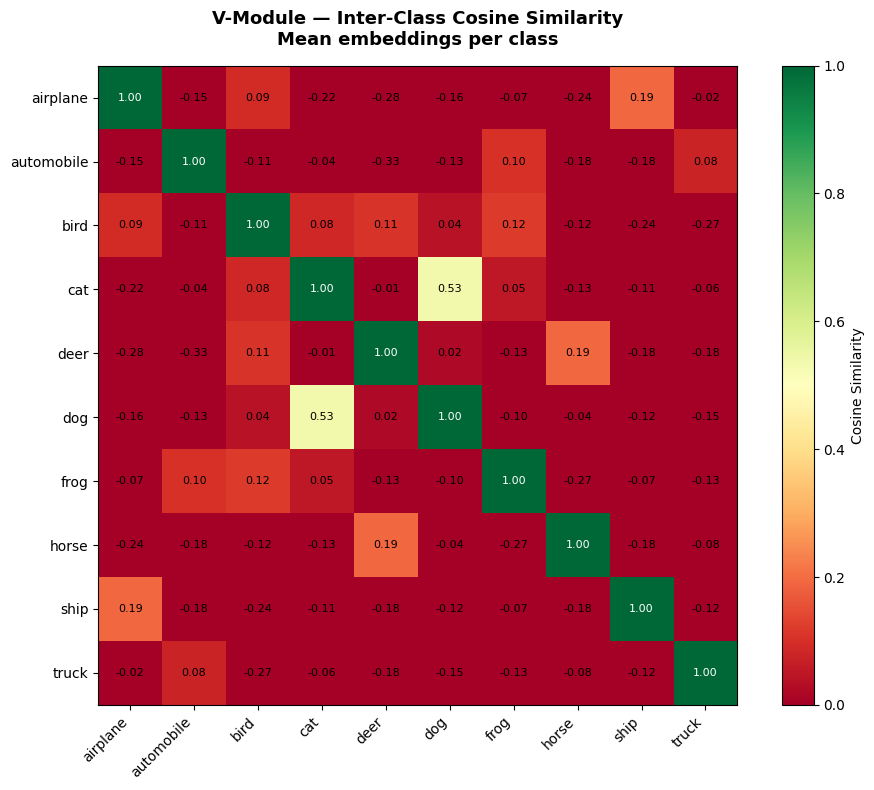

Saved vatsa_visual_similarity.png


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# Mean embedding per class
visual_class_means = np.array([
    visual_embeddings[visual_labels == i].mean(axis=0)
    for i in range(10)
])

sim_matrix = cosine_similarity(visual_class_means)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(CIFAR10_CLASSES, fontsize=10)

# Annotate cells
for i in range(10):
    for j in range(10):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}",
                ha='center', va='center', fontsize=8,
                color='black' if sim_matrix[i,j] < 0.8 else 'white')

plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_title("V-Module — Inter-Class Cosine Similarity\n"
             "Mean embeddings per class",
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig("vatsa_visual_similarity.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved vatsa_visual_similarity.png")

## 10. Embedding Norm Distribution

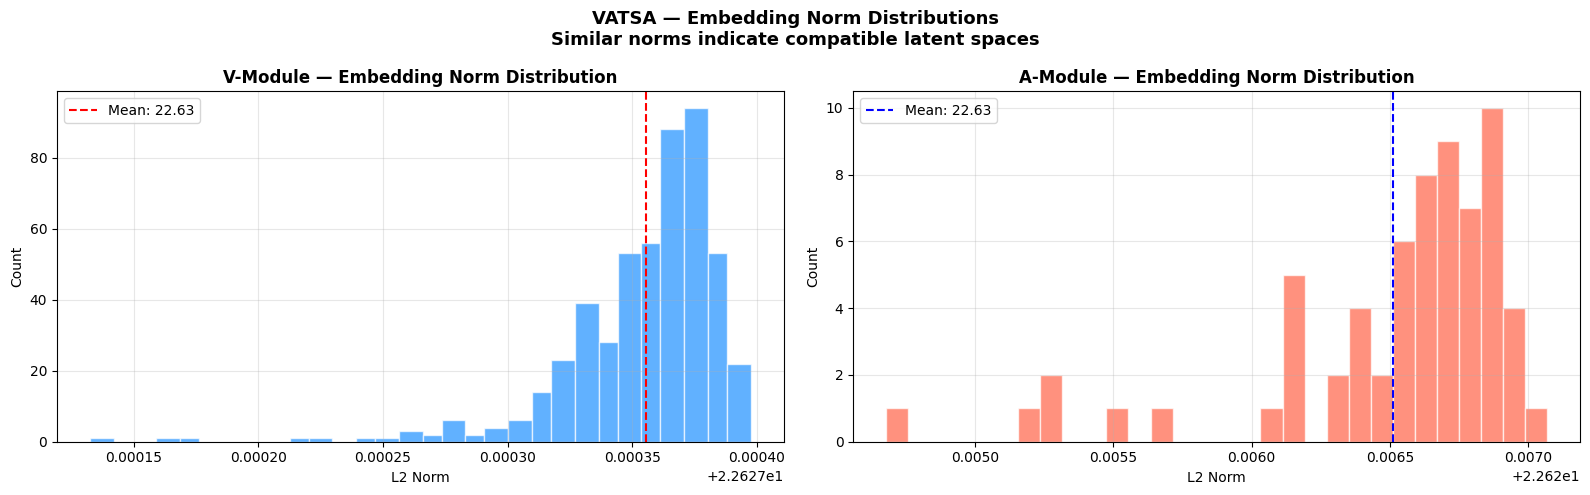

Saved vatsa_norm_distribution.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Visual norms
v_norms = np.linalg.norm(visual_embeddings, axis=1)
axes[0].hist(v_norms, bins=30, color='#1E90FF', alpha=0.7, edgecolor='white')
axes[0].set_title("V-Module — Embedding Norm Distribution", fontweight='bold')
axes[0].set_xlabel("L2 Norm")
axes[0].set_ylabel("Count")
axes[0].axvline(v_norms.mean(), color='red', linestyle='--',
                label=f'Mean: {v_norms.mean():.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Audio norms
a_norms = np.linalg.norm(audio_embeddings, axis=1)
axes[1].hist(a_norms, bins=30, color='#FF6347', alpha=0.7, edgecolor='white')
axes[1].set_title("A-Module — Embedding Norm Distribution", fontweight='bold')
axes[1].set_xlabel("L2 Norm")
axes[1].set_ylabel("Count")
axes[1].axvline(a_norms.mean(), color='blue', linestyle='--',
                label=f'Mean: {a_norms.mean():.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("VATSA — Embedding Norm Distributions\n"
             "Similar norms indicate compatible latent spaces",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("vatsa_norm_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved vatsa_norm_distribution.png")

## 11. Summary

In [22]:
print("=" * 55)
print("VATSA EMBEDDING ANALYSIS SUMMARY")
print("=" * 55)
print(f"\nVisual Embeddings")
print(f"  Samples:     {len(visual_embeddings)}")
print(f"  Shape:       {visual_embeddings.shape}")
print(f"  Norm mean:   {v_norms.mean():.4f}")
print(f"  Norm std:    {v_norms.std():.4f}")

print(f"\nAudio Embeddings")
print(f"  Samples:     {len(audio_embeddings)}")
print(f"  Shape:       {audio_embeddings.shape}")
print(f"  Norm mean:   {a_norms.mean():.4f}")
print(f"  Norm std:    {a_norms.std():.4f}")

print(f"\nSaved plots:")
print(f"  vatsa_visual_tsne.png")
print(f"  vatsa_audio_tsne.png")
print(f"  vatsa_embedding_comparison.png  ← use this for social posts")
print(f"  vatsa_visual_similarity.png")
print(f"  vatsa_norm_distribution.png")
print("=" * 55)

VATSA EMBEDDING ANALYSIS SUMMARY

Visual Embeddings
  Samples:     500
  Shape:       (500, 512)
  Norm mean:   22.6274
  Norm std:    0.0000

Audio Embeddings
  Samples:     65
  Shape:       (65, 512)
  Norm mean:   22.6265
  Norm std:    0.0005

Saved plots:
  vatsa_visual_tsne.png
  vatsa_audio_tsne.png
  vatsa_embedding_comparison.png  ← use this for social posts
  vatsa_visual_similarity.png
  vatsa_norm_distribution.png
